<a href="https://colab.research.google.com/github/duypham31251023685/python_chamem/blob/main/btvn_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install numpy scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 3.9 MB/s eta 0:00:00


In [5]:
pip install matplotlib

--- KẾT QUẢ TÍNH TOÁN HỆ THỐNG MỜ TÍCH HỢP ---
Giá đi xe dự kiến: 80.00%
Điểm thưởng dự kiến: 90.71%


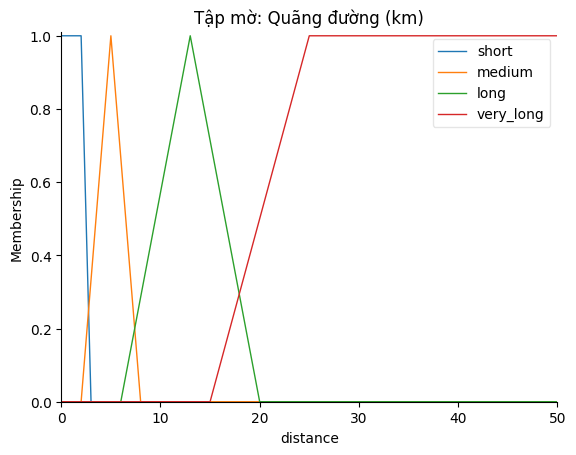

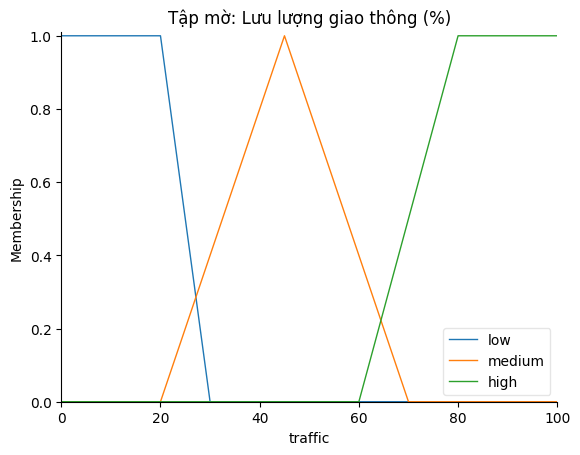

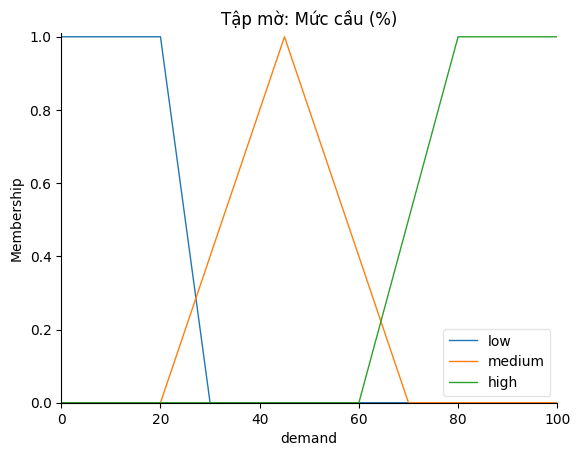

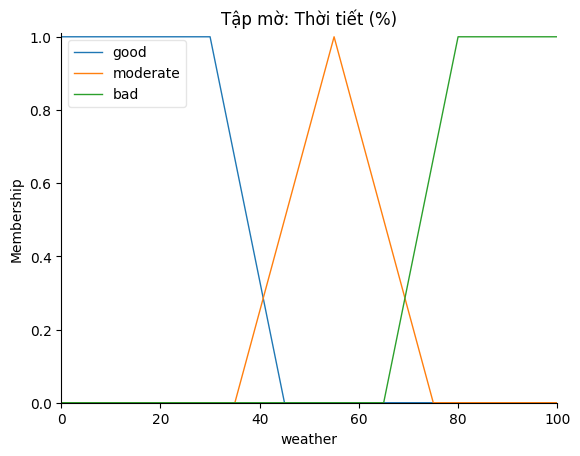

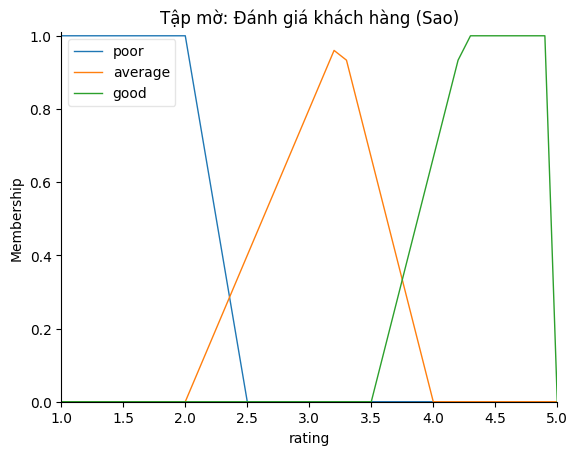

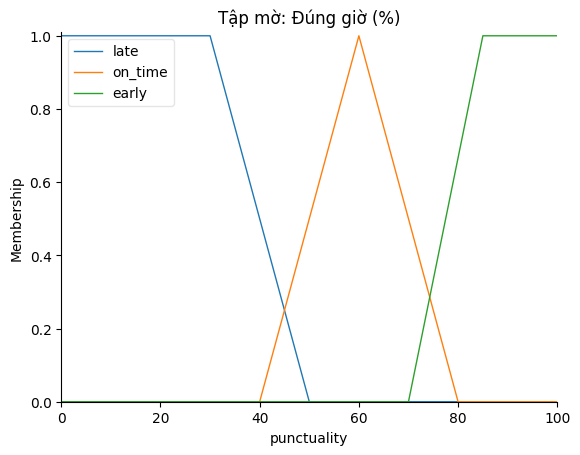

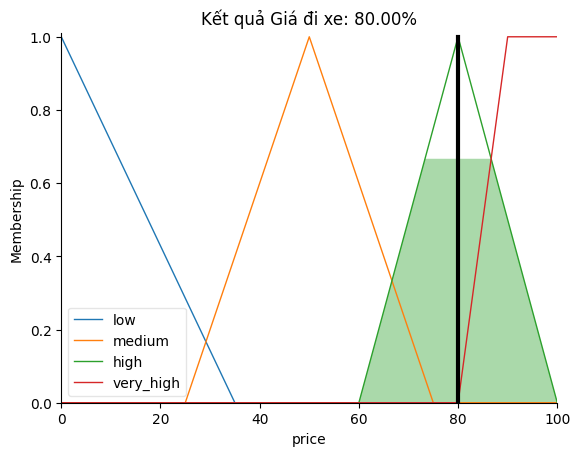

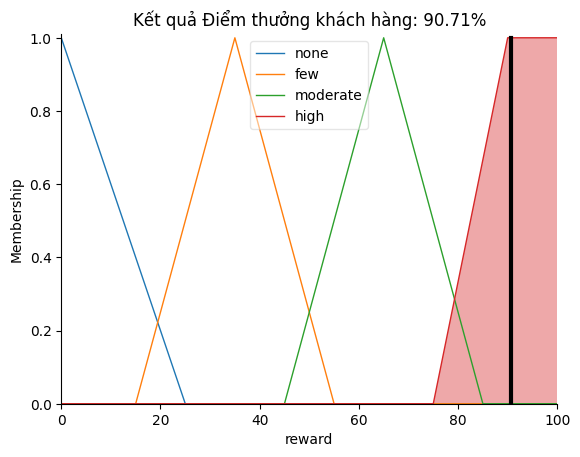

In [3]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# =================================================================
# 1. KHAI BÁO CÁC BIẾN VÀO (INPUTS) VÀ BIẾN RA (OUTPUTS)
# =================================================================

# --- Các biến vào (Inputs) ---
distance = ctrl.Antecedent(np.arange(0, 51, 1), 'distance')         # Quãng đường: 0 - 50 km
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')          # Lưu lượng: 0 - 100%
demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')            # Mức cầu: 0 - 100%
weather = ctrl.Antecedent(np.arange(0, 101, 1), 'weather')          # Thời tiết: 0 - 100% (Tốt -> Xấu)
rating = ctrl.Antecedent(np.arange(1.0, 5.1, 0.1), 'rating')        # Đánh giá khách hàng: 1.0 - 5.0 sao
punctuality = ctrl.Antecedent(np.arange(0, 101, 1), 'punctuality')  # Đúng giờ: 0 - 100%

# --- Các biến ra (Outputs) ---
price = ctrl.Consequent(np.arange(0, 101, 1), 'price')              # Giá đi xe: 0 - 100
reward = ctrl.Consequent(np.arange(0, 101, 1), 'reward')            # Điểm thưởng: 0 - 100

# =================================================================
# 2. ĐỊNH NGHĨA CÁC TẬP MỜ (MEMBERSHIP FUNCTIONS)
# =================================================================

# --- Biến vào: Quãng đường (Distance) ---
distance['short'] = fuzz.trapmf(distance.universe, [0, 0, 2, 3])
distance['medium'] = fuzz.trimf(distance.universe, [2, 5, 8])
distance['long'] = fuzz.trimf(distance.universe, [6, 13, 20])
distance['very_long'] = fuzz.trapmf(distance.universe, [15, 25, 50, 50])

# --- Biến vào: Lưu lượng giao thông (Traffic) ---
traffic['low'] = fuzz.trapmf(traffic.universe, [0, 0, 20, 30])
traffic['medium'] = fuzz.trimf(traffic.universe, [20, 45, 70])
traffic['high'] = fuzz.trapmf(traffic.universe, [60, 80, 100, 100])

# --- Biến vào: Mức cầu (Demand) ---
demand['low'] = fuzz.trapmf(demand.universe, [0, 0, 20, 30])
demand['medium'] = fuzz.trimf(demand.universe, [20, 45, 70])
demand['high'] = fuzz.trapmf(demand.universe, [60, 80, 100, 100])

# --- Biến vào: Thời tiết (Weather) ---
weather['good'] = fuzz.trapmf(weather.universe, [0, 0, 30, 45])
weather['moderate'] = fuzz.trimf(weather.universe, [35, 55, 75])
weather['bad'] = fuzz.trapmf(weather.universe, [65, 80, 100, 100])

# --- Biến vào: Đánh giá khách hàng (Rating) ---
rating['poor'] = fuzz.trapmf(rating.universe, [1.0, 1.0, 2.0, 2.5])
rating['average'] = fuzz.trimf(rating.universe, [2.0, 3.25, 4.0])
rating['good'] = fuzz.trapmf(rating.universe, [3.5, 4.25, 5.0, 5.0])

# --- Biến vào: Đúng giờ (Punctuality) ---
punctuality['late'] = fuzz.trapmf(punctuality.universe, [0, 0, 30, 50])
punctuality['on_time'] = fuzz.trimf(punctuality.universe, [40, 60, 80])
punctuality['early'] = fuzz.trapmf(punctuality.universe, [70, 85, 100, 100])


# --- Biến ra: Giá đi xe (Price) ---
price['low'] = fuzz.trimf(price.universe, [0, 0, 35])
price['medium'] = fuzz.trimf(price.universe, [25, 50, 75])
price['high'] = fuzz.trimf(price.universe, [60, 80, 100])
price['very_high'] = fuzz.trapmf(price.universe, [80, 90, 100, 100])

# --- Biến ra: Điểm thưởng (Reward) ---
reward['none'] = fuzz.trimf(reward.universe, [0, 0, 25])
reward['few'] = fuzz.trimf(reward.universe, [15, 35, 55])
reward['moderate'] = fuzz.trimf(reward.universe, [45, 65, 85])
reward['high'] = fuzz.trapmf(reward.universe, [75, 90, 100, 100])

# =================================================================
# 3. THIẾT LẬP TOÀN BỘ CÁC LUẬT MỜ (FUZZY RULES)
# =================================================================

rules = [
    # --- Nhóm 1: Xác định Giá đi xe ---
    ctrl.Rule(distance['short'] & traffic['low'] & demand['low'], price['low']),
    ctrl.Rule(distance['short'] & traffic['medium'] & demand['high'], price['medium']),
    ctrl.Rule(distance['medium'] & traffic['high'] & demand['high'], price['high']),
    ctrl.Rule(distance['long'] & traffic['medium'] & weather['good'], price['medium']),
    ctrl.Rule(distance['long'] & traffic['high'] & weather['bad'], price['very_high']),
    ctrl.Rule(distance['very_long'] & traffic['high'] & demand['high'], price['very_high']),
    ctrl.Rule(distance['medium'] & traffic['low'] & demand['low'], price['medium']),
    ctrl.Rule(distance['short'] & traffic['high'] & weather['bad'], price['high']),
    ctrl.Rule(distance['very_long'] & weather['bad'], price['very_high']),
    ctrl.Rule(distance['medium'] & traffic['medium'] & weather['moderate'], price['medium']),

    # --- Nhóm 2: Xác định Điểm thưởng cho khách hàng ---
    ctrl.Rule(rating['good'] & punctuality['early'], reward['high']),
    ctrl.Rule(rating['average'] & punctuality['on_time'], reward['moderate']),
    ctrl.Rule(rating['poor'] & punctuality['late'], reward['none']),
    ctrl.Rule(distance['long'] & traffic['high'] & punctuality['on_time'], reward['high']),
    ctrl.Rule(distance['medium'] & traffic['medium'] & rating['good'], reward['moderate']),
    ctrl.Rule(rating['poor'] & punctuality['late'], reward['none']),
    ctrl.Rule(distance['very_long'] & weather['bad'] & rating['good'], reward['high']),
    ctrl.Rule(distance['short'] & rating['average'] & punctuality['on_time'], reward['few']),
    ctrl.Rule(distance['long'] & traffic['high'] & punctuality['late'], reward['few']),
    ctrl.Rule(distance['medium'] & weather['moderate'] & rating['good'], reward['moderate'])
]

# =================================================================
# 4. KHỞI TẠO VÀ CHẠY MÔ PHỎNG
# =================================================================

tipping_ctrl = ctrl.ControlSystem(rules)
tipping = ctrl.ControlSystemSimulation(tipping_ctrl)

tipping.input['distance'] = 4.0
tipping.input['traffic'] = 75
tipping.input['demand'] = 80
tipping.input['weather'] = 20
tipping.input['rating'] = 4.5
tipping.input['punctuality'] = 85

tipping.compute()

calc_price = tipping.output['price']
calc_reward = tipping.output['reward']

print("--- KẾT QUẢ TÍNH TOÁN HỆ THỐNG MỜ TÍCH HỢP ---")
print(f"Giá đi xe dự kiến: {calc_price:.2f}%")
print(f"Điểm thưởng dự kiến: {calc_reward:.2f}%")

distance.view()
plt.title('Tập mờ: Quãng đường (km)')

traffic.view()
plt.title('Tập mờ: Lưu lượng giao thông (%)')

demand.view()
plt.title('Tập mờ: Mức cầu (%)')

weather.view()
plt.title('Tập mờ: Thời tiết (%)')

rating.view()
plt.title('Tập mờ: Đánh giá khách hàng (Sao)')

punctuality.view()
plt.title('Tập mờ: Đúng giờ (%)')

price.view(sim=tipping)
plt.title(f'Kết quả Giá đi xe: {calc_price:.2f}%')

reward.view(sim=tipping)
plt.title(f'Kết quả Điểm thưởng khách hàng: {calc_reward:.2f}%')

plt.show()

--- KẾT QUẢ TÍNH TOÁN HỆ THỐNG MỜ TIPPING ---
Mức chiết khấu đề xuất: 58.33%


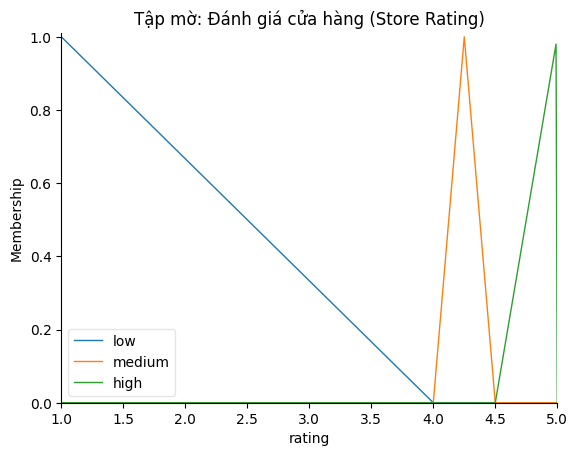

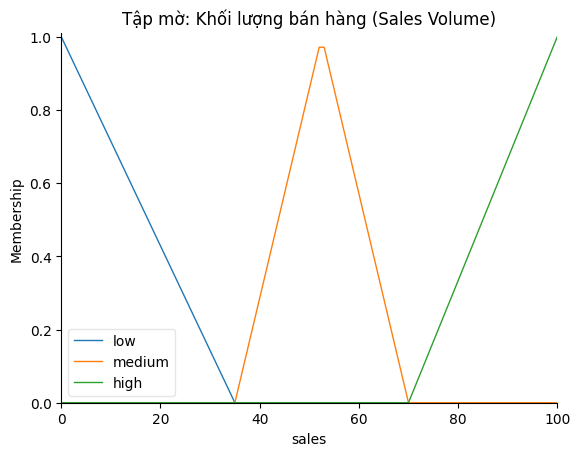

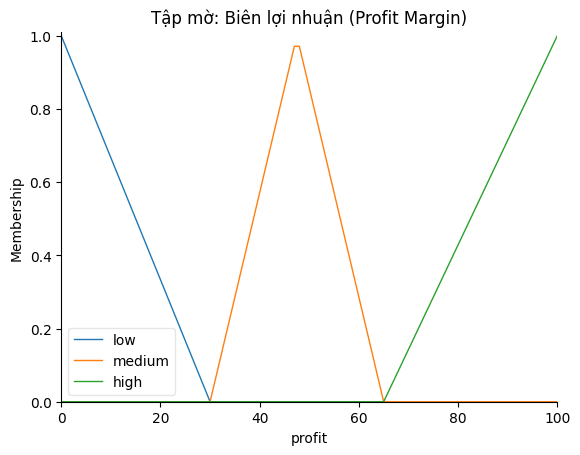

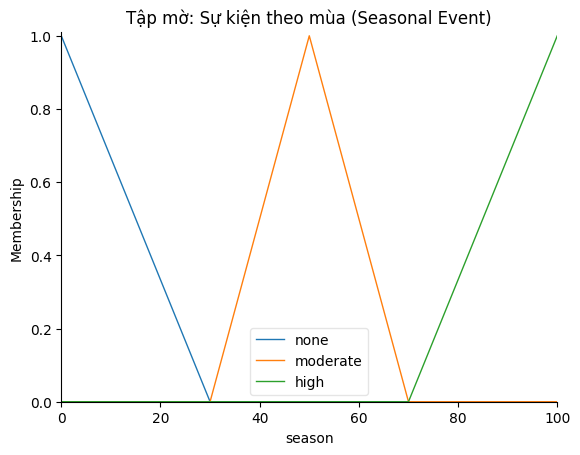

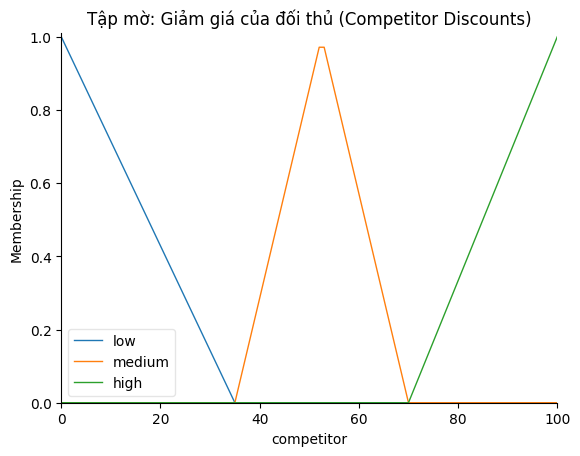

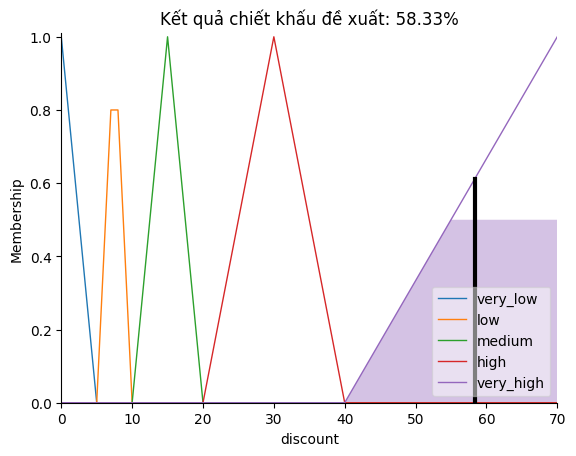

In [6]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# =================================================================
# 1. KHAI BÁO CÁC BIẾN VÀO (INPUTS) VÀ BIẾN RA (OUTPUTS)
# =================================================================

# --- Các biến vào (Inputs) ---
# Đánh giá cửa hàng (Store Rating): 1.0 - 5.0 sao
rating = ctrl.Antecedent(np.arange(1.0, 5.01, 0.01), 'rating')

# Khối lượng bán hàng (Sales Volume): 0 - 100%
sales = ctrl.Antecedent(np.arange(0, 101, 1), 'sales')

# Biên lợi nhuận (Profit Margin): 0 - 100%
profit = ctrl.Antecedent(np.arange(0, 101, 1), 'profit')

# Sự kiện theo mùa (Seasonal Event): 0 - 100%
season = ctrl.Antecedent(np.arange(0, 101, 1), 'season')

# Giảm giá của đối thủ (Competitor Discounts): 0 - 100%
competitor = ctrl.Antecedent(np.arange(0, 101, 1), 'competitor')


# --- Biến ra (Outputs) ---
# Tỷ lệ phần trăm chiết khấu: 0 - 70%
discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')

# =================================================================
# 2. ĐỊNH NGHĨA CÁC TẬP MỜ DẠNG HÌNH TAM GIÁC (TRIANGLE)
# =================================================================

# --- 1. Đánh giá cửa hàng (Store Rating) ---
rating['low'] = fuzz.trimf(rating.universe, [1.0, 1.0, 4.0])
rating['medium'] = fuzz.trimf(rating.universe, [4.0, 4.25, 4.5])
rating['high'] = fuzz.trimf(rating.universe, [4.5, 5.0, 5.0])

# --- 2. Khối lượng bán hàng (Sales Volume) ---
sales['low'] = fuzz.trimf(sales.universe, [0, 0, 35])
sales['medium'] = fuzz.trimf(sales.universe, [35, 52.5, 70])
sales['high'] = fuzz.trimf(sales.universe, [70, 100, 100])

# --- 3. Biên lợi nhuận (Profit Margin) ---
profit['low'] = fuzz.trimf(profit.universe, [0, 0, 30])
profit['medium'] = fuzz.trimf(profit.universe, [30, 47.5, 65])
profit['high'] = fuzz.trimf(profit.universe, [65, 100, 100])

# --- 4. Sự kiện theo mùa (Seasonal Event) ---
season['none'] = fuzz.trimf(season.universe, [0, 0, 30])
season['moderate'] = fuzz.trimf(season.universe, [30, 50, 70])
season['high'] = fuzz.trimf(season.universe, [70, 100, 100])

# --- 5. Giảm giá của đối thủ (Competitor Discounts) ---
competitor['low'] = fuzz.trimf(competitor.universe, [0, 0, 35])
competitor['medium'] = fuzz.trimf(competitor.universe, [35, 52.5, 70])
competitor['high'] = fuzz.trimf(competitor.universe, [70, 100, 100])


# --- BIẾN RA: Tỷ lệ phần trăm chiết khấu (Discount) ---
discount['very_low'] = fuzz.trimf(discount.universe, [0, 0, 5])
discount['low'] = fuzz.trimf(discount.universe, [5, 7.5, 10])
discount['medium'] = fuzz.trimf(discount.universe, [10, 15, 20])
discount['high'] = fuzz.trimf(discount.universe, [20, 30, 40])
discount['very_high'] = fuzz.trimf(discount.universe, [40, 70, 70])

# =================================================================
# 3. THIẾT LẬP CÁC LUẬT MỜ (FUZZY RULES)
# =================================================================

rules = [
    ctrl.Rule(rating['high'] & sales['high'] & profit['high'], discount['very_low']),
    ctrl.Rule(rating['low'] & sales['low'] & profit['high'], discount['high']),
    ctrl.Rule(season['high'] & competitor['high'], discount['very_high']),
    ctrl.Rule(rating['medium'] & sales['medium'] & profit['medium'], discount['medium']),
    ctrl.Rule(competitor['low'] & profit['low'] & sales['high'], discount['very_low']),
    ctrl.Rule(rating['low'] & season['none'], discount['medium']),
    ctrl.Rule(sales['low'] & profit['low'], discount['very_high'])
]

# =================================================================
# 4. KHỞI TẠO VÀ CHẠY MÔ PHỎNG
# =================================================================

tipping_ctrl = ctrl.ControlSystem(rules)
tipping = ctrl.ControlSystemSimulation(tipping_ctrl)

tipping.input['rating'] = 4.3
tipping.input['sales'] = 50
tipping.input['profit'] = 15
tipping.input['season'] = 85
tipping.input['competitor'] = 90

tipping.compute()

calculated_discount = tipping.output['discount']

print("--- KẾT QUẢ TÍNH TOÁN HỆ THỐNG MỜ TIPPING ---")
print(f"Mức chiết khấu đề xuất: {calculated_discount:.2f}%")

# =================================================================
# 5. TRỰC QUAN HÓA TOÀN BỘ BIẾN VÀO VÀ BIẾN RA
# =================================================================

# Trực quan hóa các biến vào (Không dùng hàm cũ nữa)
rating.view()
plt.title('Tập mờ: Đánh giá cửa hàng (Store Rating)')

sales.view()
plt.title('Tập mờ: Khối lượng bán hàng (Sales Volume)')

profit.view()
plt.title('Tập mờ: Biên lợi nhuận (Profit Margin)')

season.view()
plt.title('Tập mờ: Sự kiện theo mùa (Seasonal Event)')

competitor.view()
plt.title('Tập mờ: Giảm giá của đối thủ (Competitor Discounts)')

# Trực quan hóa biến ra kèm kết quả tính toán
discount.view(sim=tipping)
plt.title(f'Kết quả chiết khấu đề xuất: {calculated_discount:.2f}%')

plt.show()

--- KẾT QUẢ TÍNH TOÁN HỆ THỐNG MỜ TIPPING ---
Mức chiết khấu đề xuất: 20.00%


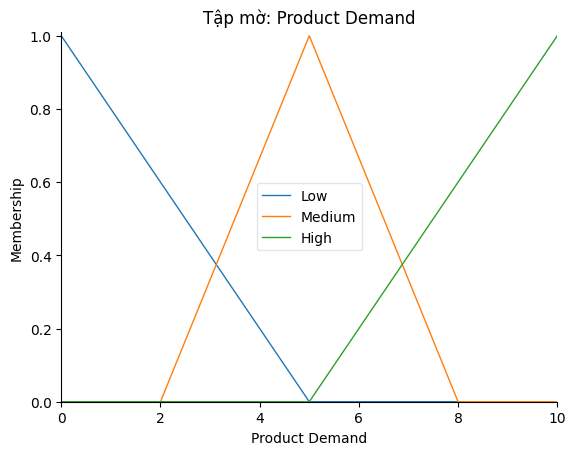

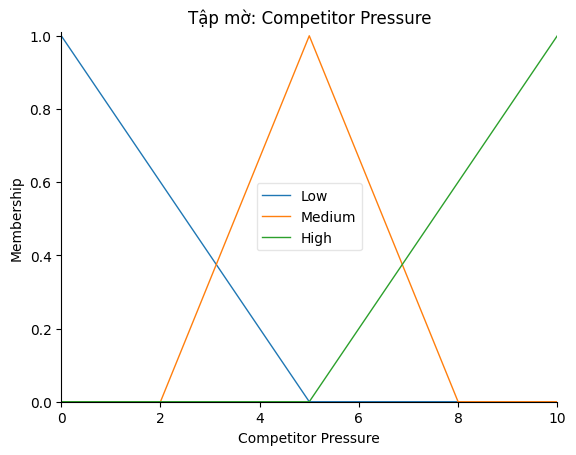

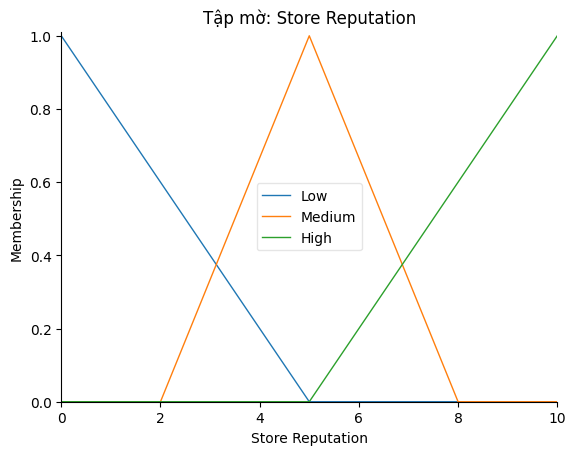

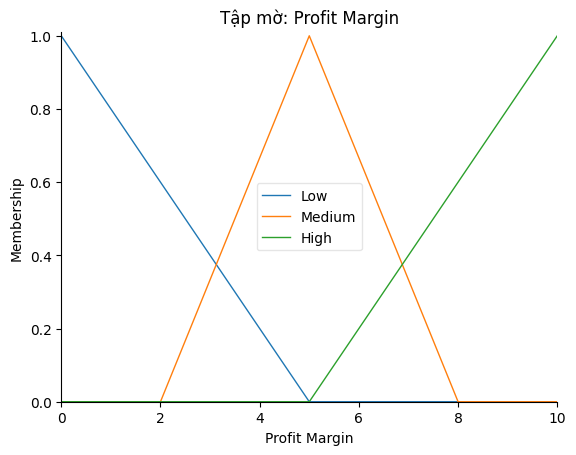

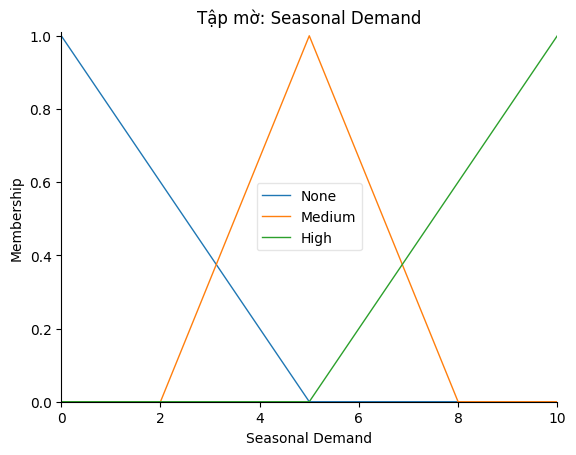

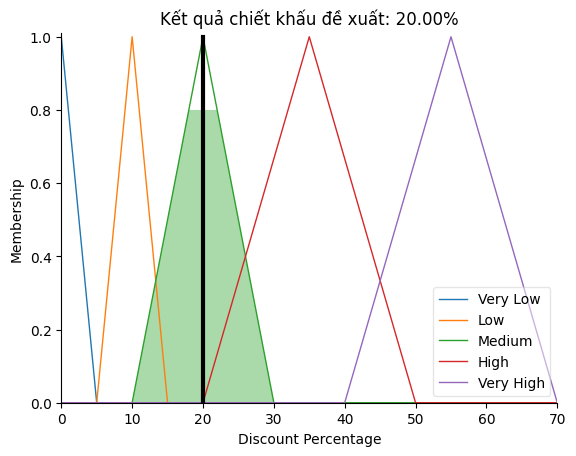

In [7]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# ==========================================
# 1. KHỞI TẠO CÁC BIẾN VÀO (ANTECEDENTS) VÀ BIẾN RA (CONSEQUENTS)
# ==========================================

# Các biến đầu vào được chuẩn hóa trên thang điểm từ 0 đến 10
demand = ctrl.Antecedent(np.arange(0, 11, 1), 'Product Demand')
competition = ctrl.Antecedent(np.arange(0, 11, 1), 'Competitor Pressure')
reputation = ctrl.Antecedent(np.arange(0, 11, 1), 'Store Reputation')
margin = ctrl.Antecedent(np.arange(0, 11, 1), 'Profit Margin')
seasonal = ctrl.Antecedent(np.arange(0, 11, 1), 'Seasonal Demand')

# Biến đầu ra: Phần trăm giảm giá (Discount Percentage) từ 0% đến 70%
discount = ctrl.Consequent(np.arange(0, 71, 1), 'Discount Percentage')

# ==========================================
# 2. ĐỊNH NGHĨA CÁC TẬP MỜ (MEMBERSHIP FUNCTIONS)
# ==========================================

# Định nghĩa hàm tư cách cho các biến đầu vào (Thấp, Trung bình, Cao)
for var in [demand, competition, reputation, margin]:
    var['Low'] = fuzz.trimf(var.universe, [0, 0, 5])
    var['Medium'] = fuzz.trimf(var.universe, [2, 5, 8])
    var['High'] = fuzz.trimf(var.universe, [5, 10, 10])

# Riêng biến Seasonal Demand có 3 mức: None, Medium, High
seasonal['None'] = fuzz.trimf(seasonal.universe, [0, 0, 5])
seasonal['Medium'] = fuzz.trimf(seasonal.universe, [2, 5, 8])
seasonal['High'] = fuzz.trimf(seasonal.universe, [5, 10, 10])

# Định nghĩa hàm tư cách cho biến đầu ra Discount Percentage
discount['Very Low'] = fuzz.trimf(discount.universe, [0, 0, 5])
discount['Low'] = fuzz.trimf(discount.universe, [5, 10, 15])
discount['Medium'] = fuzz.trimf(discount.universe, [10, 20, 30])
discount['High'] = fuzz.trimf(discount.universe, [20, 35, 50])
discount['Very High'] = fuzz.trimf(discount.universe, [40, 55, 70])

# ==========================================
# 3. THIẾT LẬP CÁC LUẬT MỜ (FUZZY RULES)
# ==========================================

rule1 = ctrl.Rule(demand['High'] & competition['Low'] & margin['Low'], discount['Very Low'])
rule2 = ctrl.Rule(demand['Low'] & competition['High'] & margin['High'], discount['High'])
rule3 = ctrl.Rule(reputation['High'] & margin['Medium'] & seasonal['High'], discount['Medium'])
rule4 = ctrl.Rule(competition['High'] & seasonal['High'] & margin['High'], discount['Very High'])
rule5 = ctrl.Rule(reputation['Low'] & demand['Medium'] & margin['Low'], discount['Medium'])
rule6 = ctrl.Rule(demand['High'] & seasonal['None'] & competition['Low'], discount['Very Low'])
rule7 = ctrl.Rule(margin['High'] & seasonal['High'] & competition['Medium'], discount['Medium'])

# ==========================================
# 4. HỆ THỐNG ĐIỀU KHIỂN VÀ MÔ PHỎNG
# ==========================================

tipping_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
tipping = ctrl.ControlSystemSimulation(tipping_ctrl)

# Nhập các giá trị rõ (crisp values)
tipping.input['Product Demand'] = 8.5        # Nhu cầu: Cao
tipping.input['Competitor Pressure'] = 5.0   # Áp lực đối thủ: Trung bình
tipping.input['Store Reputation'] = 6.0      # Uy tín: Trung bình
tipping.input['Profit Margin'] = 9.0         # Biên lợi nhuận: Cao
tipping.input['Seasonal Demand'] = 9.0       # Nhu cầu theo mùa: Cao

# Tính toán kết quả mờ hóa và giải mờ
tipping.compute()

# Lưu và in kết quả phần trăm giảm giá ra màn hình
calculated_discount = tipping.output['Discount Percentage']

print("--- KẾT QUẢ TÍNH TOÁN HỆ THỐNG MỜ TIPPING ---")
print(f"Mức chiết khấu đề xuất: {calculated_discount:.2f}%")

# ==========================================
# 5. TRỰC QUAN HÓA CÁC BIẾN VÀO/RA VÀ KẾT QUẢ (SỬA THÀNH TIPPING)
# ==========================================

# Trực quan hóa các tập mờ của biến đầu vào
demand.view()
plt.title('Tập mờ: Product Demand')

competition.view()
plt.title('Tập mờ: Competitor Pressure')

reputation.view()
plt.title('Tập mờ: Store Reputation')

margin.view()
plt.title('Tập mờ: Profit Margin')

seasonal.view()
plt.title('Tập mờ: Seasonal Demand')

# Trực quan hóa biến đầu ra và đánh dấu giá trị giải mờ cụ thể của tình huống
discount.view(sim=tipping)
plt.title(f'Kết quả chiết khấu đề xuất: {calculated_discount:.2f}%')

# Hiển thị tất cả các đồ thị đã vẽ
plt.show()

--------------------------------------------------
KẾT QUẢ GIẢI MỜ:
- Mức độ ưu tiên giao hàng: 5.59/10
- Số lượng đơn hàng cần kết hợp: 8.14/10
--------------------------------------------------


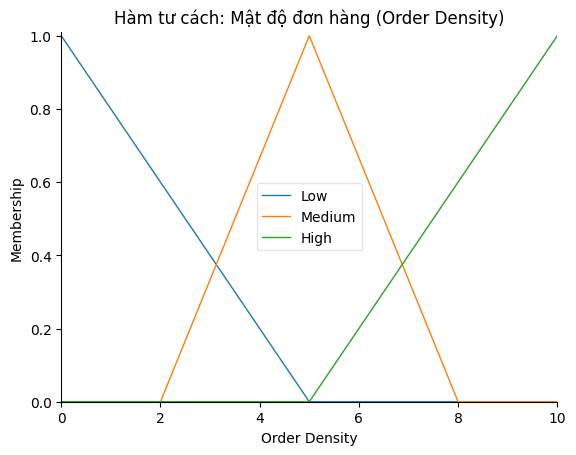

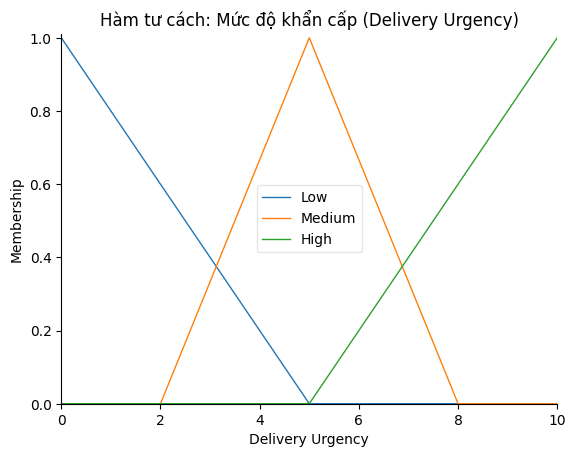

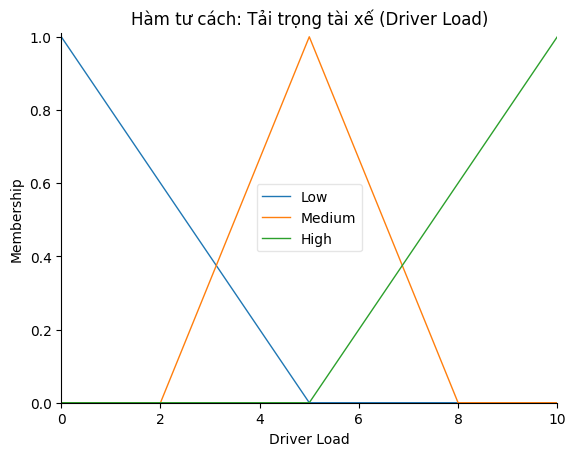

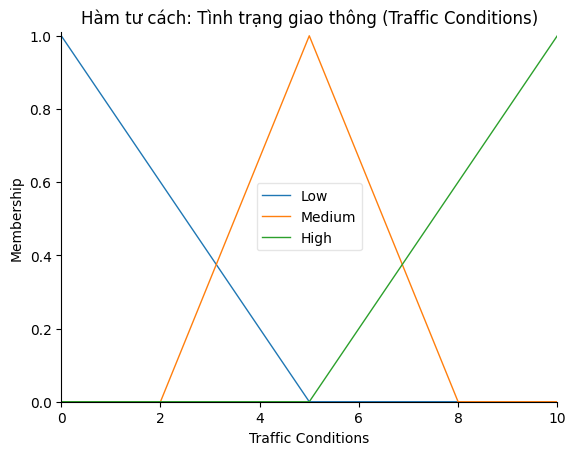

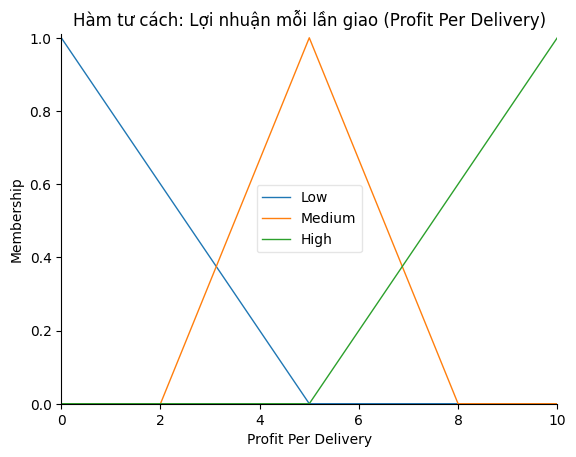

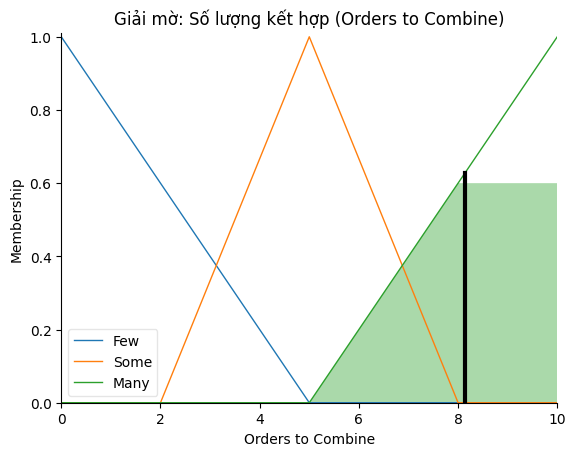

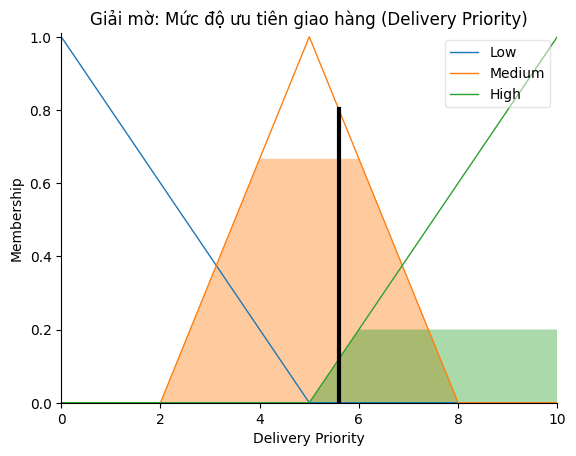

In [30]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# ==========================================
# 1. KHỞI TẠO CÁC BIẾN VÀO (ANTECEDENTS) VÀ BIẾN RA (CONSEQUENTS)
# ==========================================
density = ctrl.Antecedent(np.arange(0, 11, 1), 'Order Density')       # Mật độ đơn hàng
urgency = ctrl.Antecedent(np.arange(0, 11, 1), 'Delivery Urgency')    # Mức độ khẩn cấp
load = ctrl.Antecedent(np.arange(0, 11, 1), 'Driver Load')            # Tải trọng tài xế
traffic = ctrl.Antecedent(np.arange(0, 11, 1), 'Traffic Conditions')  # Tình trạng giao thông
profit = ctrl.Antecedent(np.arange(0, 11, 1), 'Profit Per Delivery')  # Lợi nhuận mỗi lần giao

# Biến đầu ra
combine = ctrl.Consequent(np.arange(0, 11, 1), 'Orders to Combine')    # Số lượng kết hợp
priority = ctrl.Consequent(np.arange(0, 11, 1), 'Delivery Priority')  # Mức độ ưu tiên

# ==========================================
# 2. ĐỊNH NGHĨA CÁC TẬP MỜ (MEMBERSHIP FUNCTIONS)
# ==========================================
# Thấp, Trung bình, Cao cho các biến đầu vào
for var in [density, urgency, load, traffic, profit]:
    var['Low'] = fuzz.trimf(var.universe, [0, 0, 5])
    var['Medium'] = fuzz.trimf(var.universe, [2, 5, 8])
    var['High'] = fuzz.trimf(var.universe, [5, 10, 10])

# Số lượng đơn hàng (Ít, Một số, Nhiều)
combine['Few'] = fuzz.trimf(combine.universe, [0, 0, 5])
combine['Some'] = fuzz.trimf(combine.universe, [2, 5, 8])
combine['Many'] = fuzz.trimf(combine.universe, [5, 10, 10])

# Mức độ ưu tiên (Thấp, Trung bình, Cao)
priority['Low'] = fuzz.trimf(priority.universe, [0, 0, 5])
priority['Medium'] = fuzz.trimf(priority.universe, [2, 5, 8])
priority['High'] = fuzz.trimf(priority.universe, [5, 10, 10])

# ==========================================
# 3. THIẾT LẬP CÁC LUẬT MỜ (FUZZY RULES)
# ==========================================
rule1 = ctrl.Rule(density['High'] & load['Low'] & traffic['Low'], combine['Many'])
rule2 = ctrl.Rule(density['Medium'] & traffic['High'] & urgency['Medium'], combine['Some'])
rule3 = ctrl.Rule(load['High'] & density['High'] & profit['Medium'], combine['Some'])
rule4 = ctrl.Rule(density['Low'] & urgency['High'] & traffic['Medium'], combine['Some'])
rule5 = ctrl.Rule(profit['High'] & urgency['High'] & traffic['High'], combine['Some'])

rule6 = ctrl.Rule(urgency['High'] & profit['High'], priority['High'])
rule7 = ctrl.Rule(urgency['Medium'] & traffic['Medium'], priority['Medium'])
rule8 = ctrl.Rule(urgency['Low'] & density['High'] & profit['Low'], priority['Low'])

# Luật 9 dựa trên kết luận tình huống thực tế
rule9 = ctrl.Rule(density['High'] & load['Low'], combine['Many'])

# ==========================================
# 4. HỆ THỐNG ĐIỀU KHIỂN VÀ MÔ PHỎNG
# ==========================================
logistics_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
logistics_sim = ctrl.ControlSystemSimulation(logistics_ctrl)

# Nhập dữ liệu đầu vào thực tế từ bài toán
logistics_sim.input['Order Density'] = 10
logistics_sim.input['Delivery Urgency'] = 6.0
logistics_sim.input['Driver Load'] = 2.0
logistics_sim.input['Traffic Conditions'] = 5.0
logistics_sim.input['Profit Per Delivery'] = 6.0

logistics_sim.compute()

print("-" * 50)
print(f"KẾT QUẢ GIẢI MỜ:")
print(f"- Mức độ ưu tiên giao hàng: {logistics_sim.output['Delivery Priority']:.2f}/10")
print(f"- Số lượng đơn hàng cần kết hợp: {logistics_sim.output['Orders to Combine']:.2f}/10")
print("-" * 50)

# ==========================================
# 5. TRỰC QUAN HÓA TẤT CẢ BIẾN VÀO VÀ BIẾN RA
# ==========================================

# --- TRỰC QUAN HÓA 5 BIẾN VÀO ---
density.view()
plt.title('Hàm tư cách: Mật độ đơn hàng (Order Density)')

urgency.view()
plt.title('Hàm tư cách: Mức độ khẩn cấp (Delivery Urgency)')

load.view()
plt.title('Hàm tư cách: Tải trọng tài xế (Driver Load)')

traffic.view()
plt.title('Hàm tư cách: Tình trạng giao thông (Traffic Conditions)')

profit.view()
plt.title('Hàm tư cách: Lợi nhuận mỗi lần giao (Profit Per Delivery)')

# --- TRỰC QUAN HÓA 2 BIẾN RA CÙNG KẾT QUẢ GIẢI MỜ ---
combine.view(sim=logistics_sim)
plt.title('Giải mờ: Số lượng kết hợp (Orders to Combine)')

priority.view(sim=logistics_sim)
plt.title('Giải mờ: Mức độ ưu tiên giao hàng (Delivery Priority)')

# Lệnh hiển thị tất cả đồ thị cùng lúc
plt.show()